In [67]:
import numpy as np, matplotlib.pyplot as plt, time
from astropy.table import Table
from pathlib import Path

# Import nuGundam related classes
from nugundam import (pcf, ProjectedAutoConfig,
     ProjectedBinning, ProjectedGridSpec, ProjectedCatalogColumns,
     WeightSpec, BootstrapSpec, DistanceSpec)
# Import nuGundam classes related to marked correlations
from nugundam import mpcf, AutoMarkSpec

# Marked correlations with nuGundam
-----------------
This notebook is a quick tutorial of how to calculate marked autocorrelations in projected space

## Read data

In [24]:
# Adjust BASEPATH if needed
BASEPATH = Path('./data/')
DATAFILE = BASEPATH / 'DR7-lrg-d4000.fits'
RANDFILE = BASEPATH / 'DR7-lrg-rand.fits'

data = Table.read(DATAFILE)
rans = Table.read(RANDFILE)

## 1. Create configuration and specify the mark

First we need to create a configuration object which is designed to hold several specifications of the computation to perform. In this case it corresponds to an angular auto-correlation so we use a config object of type ``ProjectedAutoConfig``. This is where you specify the estimator chosen, the binning for counting, the counting grid, the name of relevant columns in the datasets, and various other parameters.

In [59]:
config1 = ProjectedAutoConfig(
    # Choose estimator > NAT, DP, LS
    estimator = "LS",
    # Select dataset columns
    columns_data=ProjectedCatalogColumns(ra="ra", dec="dec", redshift='z'),
    columns_random=ProjectedCatalogColumns(ra="ra", dec="dec", redshift='z'),
    # Set number of threads
    nthreads = 4,
    # Specify binning in rp-direction > number_of_bins, minimum separation [Mpc/h], bin size (in dex if logsep=True)
    # Specify binning in pi-direction > number_of_bins, bin size
    binning=ProjectedBinning.from_binsize(
        nsepp=12, seppmin=0.05, dsepp=0.15, logsepp=True,   # 14 0.02 0.14
        nsepv=4, dsepv=10.0),
    # Choose counting grid and ordering 
    grid = ProjectedGridSpec(autogrid=True, pxorder="natural"),
    # Choose weight model > "auto", "weighted", "unweighted"
    weights = WeightSpec(weight_mode="unweighted"),
    # Enable boostrap error module
    bootstrap = BootstrapSpec(enabled=True, nbts=50, bseed=12345),
    # Enable distance calculation module
    distance=DistanceSpec(calcdist=True, h0=100., omegam=0.25, omegal=0.75)
)

In [60]:
mark_spec = AutoMarkSpec(column="D4000", normalize="mean")

## 2. Run correlation

Pass the data, randoms, configuration and mark specification to ``mpcf`` to perform a correlation run and obtain a result object, in this case of type ``MarkedProjectedCorrelationResult``. Once finished, it will contain all the counts, bins, correlation function, errors and relevant metadata

In [61]:
ti = time.time()
result1 = mpcf(data, rans, config1, mark=mark_spec)
print(f'elapsed time [s]: {time.time()-ti:.3f}')

[pcf] preparing data and randoms
[pcf] counting DD / RR / DR with estimator=LS


[pcf] estimating correlation
[pcf] done
[pcf] preparing data and randoms
[pcf] counting DD / RR / DR with estimator=LS


[pcf] estimating correlation
[pcf] done
elapsed time [s]: 2.456


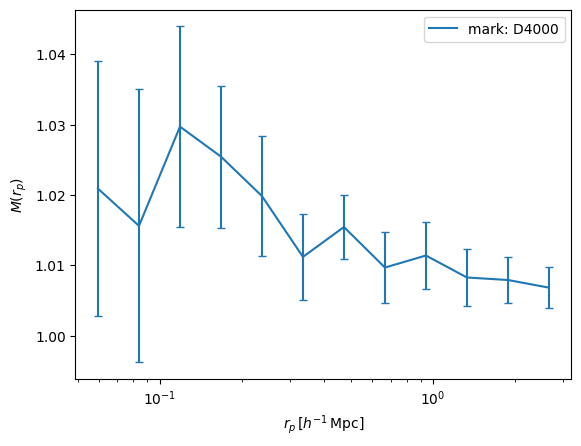

In [65]:
result1.plot(label='mark: D4000')
plt.yscale('linear')
plt.legend()

This shows that Nearby LRG neighbors tend to have D4000 slighlty higher than average, so the oldest/passivest LRGs are modestly more concentrated in close, dense environments. This is sort of expected considering these are LRG, an population of passive, red, and very homogeneous galaxies

## 3. Implementation details

In nuGundam, marked correlations are implemented as a thin layer on top of the existing weighted correlation machinery. The code performs two matched measurements with the same catalogs, geometry, estimator, and binning:

1. an ordinary unweighted correlation
2. a weighted correlation where the data objects carry the mark as their weight

These two measurements are then combined into the marked statistic. For angular auto-correlations, nuGundam defines the marked correlation as M(th) = (1+wmarked(th)) / (1+w(th)). For projected auto-correlations, it uses M(rp) = (1+wmarked(rp)/rp) / (1+w(rp)/rp).

If bootstrap or jackknife is enabled, nuGundam computes the marked statistic from matched realizations of the plain and weighted measurements, rather than combining independent error bars afterward. This gives a more correct estimate of the uncertainty and covariance of the marked correlation.

``AutoMarkSpec`` and ``CrossMarkSpec`` define which galaxy property is used as the mark and how that property is cleaned, transformed, and normalized before entering the weighted branch of the marked-correlation measurement. This class can:

* normalize to mean, median or skip normalization at all.
* use raw mark values directly or replace them by their ordinal ranks (1, 2, 3, ...,N), then normalize afterwards
* clip the raw mark values into the interval [lo, hi] before transform and normalization
* raise an error or drop the row from the calculation when its  mark column contains NaN or infinite values